# Wyznaczenie promienia krzywizny soczewki za pomocą pierścieni Newtona

In [1]:
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

## Wprowadzenie danych

In [2]:
data = {
    "r16": np.array([
        [30.14, 10.05, 17.83, 10.05, 25.00, 3.84, 25.00, 16.24],
        [30.15, 10.05, 17.84, 10.05, 25.00, 3.84, 25.00, 16.25]
    ]),

    "r18": np.array([
        [30.55, 10.05, 17.39, 10.05, 25.00, 3.33, 25.00, 16.50],
        [30.45, 10.05, 17.40, 10.05, 25.00, 3.40, 25.00, 16.49]
    ]),

    "r20": np.array([
        [31.05, 10.05, 17.20, 10.05, 25.00, 3.06, 25.00, 16.88],
        # Uwaga: Ostatnia wartość w tabeli (18.89) wygląda na błąd druku
        # względem poprzedniego wiersza, ale przepisałem ją wiernie z obrazka.
        [31.06, 10.05, 17.21, 10.05, 25.00, 3.06, 25.00, 18.89]
    ]),

    "r22": np.array([
        [31.44, 10.05, 16.85, 10.05, 25.00, 2.69, 25.00, 17.24],
        [31.43, 10.05, 16.83, 10.05, 25.00, 2.65, 25.00, 17.24]
    ]),

    "r24": np.array([
        [31.68, 10.05, 16.53, 10.05, 25.05, 2.34, 25.00, 17.52],
        [31.68, 10.05, 16.50, 10.05, 25.00, 2.35, 25.00, 17.53]
    ])
}

## Obliczenia wartości średnicy pierścieni

In [3]:
dane_sr = {}
wiersze = []  # do zbudowania tabeli wyników
for key, arr in data.items():
    # Oblicz średnie wartości dla każdego pierścienia wiedząc, że kolumny to:
    # [Lx, Ly, Px, Py, Gx, Gy, Dx, Dy]
    # Rzędy zaś, to pomiary 1 i 2
    # Średnie wartości należy obliczyć w sposób d_LP_1, d_LP_2, d_GD_1, d_GD_2, a następnie średnia z d_LP_1, d_LP_2, d_GD_1, d_GD_2
    Lx = arr[:, 0]
    Ly = arr[:, 1]
    Px = arr[:, 2]
    Py = arr[:, 3]
    Gx = arr[:, 4]
    Gy = arr[:, 5]
    Dx = arr[:, 6]
    Dy = arr[:, 7]

    d_LP_1 = np.sqrt((Lx[0] - Px[0])**2 + (Ly[0] - Py[0])**2)
    d_LP_2 = np.sqrt((Lx[1] - Px[1])**2 + (Ly[1] - Py[1])**2)
    d_GD_1 = np.sqrt((Gx[0] - Dx[0])**2 + (Gy[0] - Dy[0])**2)
    d_GD_2 = np.sqrt((Gx[1] - Dx[1])**2 + (Gy[1] - Dy[1])**2)

    d_sr = (d_LP_1 + d_LP_2 + d_GD_1 + d_GD_2) / 4
    dane_sr[key] = d_sr

    # Zapisz wartości składowe do tabeli
    wiersze.append({
        "pierścień": key,
        "d_LP_1": d_LP_1,
        "d_LP_2": d_LP_2,
        "d_GD_1": d_GD_1,
        "d_GD_2": d_GD_2,
        "d_śr": d_sr,
    })

# Utworzenie tabeli z wynikami i zapis do pliku CSV
tabela = pd.DataFrame(wiersze).set_index("pierścień").sort_index()
print("Tabela obliczonych średnic (jednostki jak w danych wejściowych):")
print(tabela)

# Zapisz tabelę do pliku CSV w tym samym folderze
csv_path = Path("tabela_srednice.csv")
# Upewnij się, że katalog docelowy istnieje
csv_path.parent.mkdir(parents=True, exist_ok=True)
tabela.to_csv(csv_path, index=True)
print(f"Zapisano tabelę do pliku: {csv_path}")



Tabela obliczonych średnic (jednostki jak w danych wejściowych):
           d_LP_1  d_LP_2     d_GD_1  d_GD_2       d_śr
pierścień                                              
r16         12.31   12.31  12.400000   12.41  12.357500
r18         13.16   13.05  13.170000   13.09  13.117500
r20         13.85   13.85  13.820000   15.83  14.337500
r22         14.59   14.60  14.550000   14.59  14.582500
r24         15.15   15.18  15.180082   15.18  15.172521
Zapisano tabelę do pliku: Sprawozdanie65/tabela_srednice.csv


## Narysowanie wykresów pierścieni Newtona

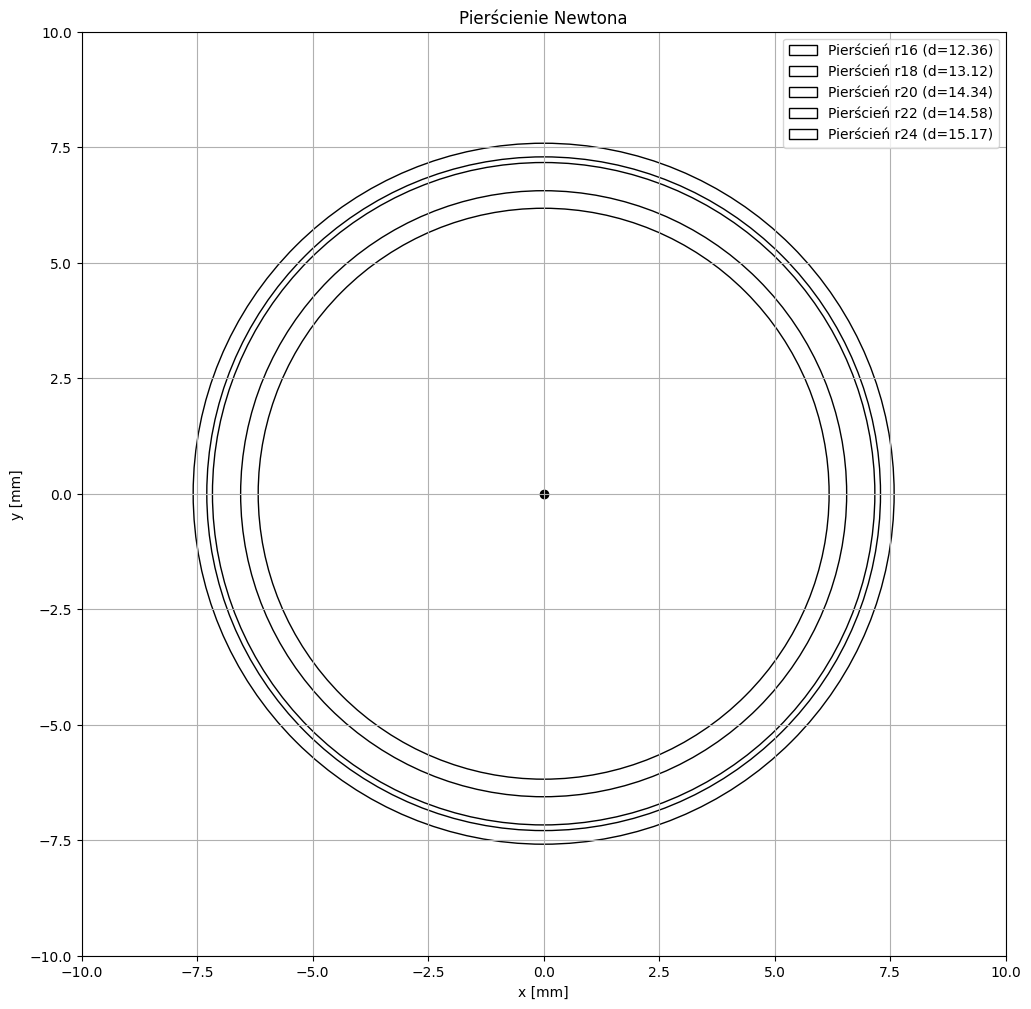

In [4]:
plt.figure(figsize=(18, 12))
# Okręgi dla każdego pierścienia
for key, d_sr in dane_sr.items():
    radius = d_sr / 2
    circle = plt.Circle((0, 0), radius, fill=False, label=f'Pierścień {key} (d={d_sr:.2f})')
    plt.gca().add_artist(circle)
plt.scatter(0, 0, color='black')  # Punkt centralny
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Pierścienie Newtona')
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
plt.grid()
plt.legend()
plt.show()